In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the raw Bronze data from our decoupled data lakehouse mount

In [10]:
eda_global_energy_generation_df = pd.read_csv('/app/data_lakehouse/release_generation_yearly_global.csv')
# Inspect raw schema and initial rows


# Show Shape

In [6]:
print(eda_global_energy_generation_df.shape)

(104099, 23)


In [11]:
print(eda_global_energy_generation_df['Continent'].value_counts())

Continent
Europe           23943
Africa           23262
Asia             23240
North America    14126
South America     6728
Oceania           6534
Name: count, dtype: int64


In [12]:
print("=== 1. STRUCTURAL PROFILE ===")
print(f"Dataset Shape: {eda_global_energy_generation_df.shape[0]} rows, {eda_global_energy_generation_df.shape[1]} columns\n")
print("Data Types and Non-Null Counts:")
print(eda_global_energy_generation_df.info())

=== 1. STRUCTURAL PROFILE ===
Dataset Shape: 104099 rows, 23 columns

Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 104099 entries, 0 to 104098
Data columns (total 23 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Area                                       104099 non-null  str    
 1   ISO 3 code                                 97833 non-null   str    
 2   Year                                       104099 non-null  int64  
 3   Area type                                  104099 non-null  str    
 4   Electricity source                         104099 non-null  str    
 5   Is aggregated source                       104099 non-null  bool   
 6   Generation (TWh)                           104099 non-null  float64
 7   Generation YoY change (TWh)                100355 non-null  float64
 8   Generation YoY change (%)                  66920 non-null   flo

# COMPLETENESS PROFILE (NULL CHECK)

In [9]:
print("\n=== 2. COMPLETENESS PROFILE (NULL CHECK) ===")

null_counts = eda_global_energy_generation_df.isnull().sum()
null_percentages = (eda_global_energy_generation_df.isnull().sum() / len(eda_global_energy_generation_df)) * 100
null_profile = pd.DataFrame({'Missing Rows': null_counts, 'Percentage (%)': null_percentages})
print(null_profile)


=== 2. COMPLETENESS PROFILE (NULL CHECK) ===
                                           Missing Rows  Percentage (%)
Area                                                  0        0.000000
ISO 3 code                                         6266        6.019270
Year                                                  0        0.000000
Area type                                             0        0.000000
Electricity source                                    0        0.000000
Is aggregated source                                  0        0.000000
Generation (TWh)                                      0        0.000000
Generation YoY change (TWh)                        3744        3.596576
Generation YoY change (%)                         37179       35.715040
Share of generation (%)                              34        0.032661
Share of generation YoY change (% points)          3778        3.629238
Emissions (MtCO2e)                                 6303        6.054813
Emissions YoY chan

# UNIQUENESS PROFILE (DUPLICATE CHECK)

In [13]:
duplicate_count = eda_global_energy_generation_df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicate_count}")
if duplicate_count > 0:
    print("\nDisplaying Duplicate Records:")
    print(eda_global_energy_generation_df[eda_global_energy_generation_df.duplicated(keep=False)])

Total Duplicate Rows Found: 0


# VALUE DISTRIBUTION (CATEGORICAL DATA)

In [14]:
print("\n=== 4. VALUE DISTRIBUTION (CATEGORICAL DATA) ===")
# Profile how many actions are coming from each continent type
print(eda_global_energy_generation_df['Continent'].value_counts(dropna=False))


=== 4. VALUE DISTRIBUTION (CATEGORICAL DATA) ===
Continent
Europe           23943
Africa           23262
Asia             23240
North America    14126
South America     6728
Oceania           6534
NaN               6266
Name: count, dtype: int64


# Visualizing the distribution using Matplotlib

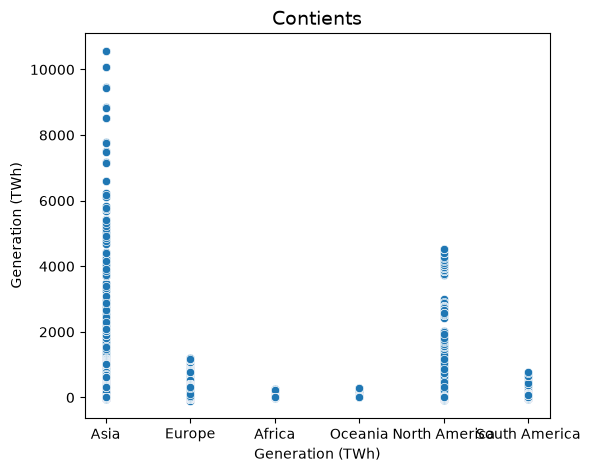

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=eda_global_energy_generation_df, x="Continent", y="Generation (TWh)", ax=ax)
ax.set_title("Contients", fontsize=14)
ax.set_xlabel("Generation (TWh)")

plt.show()